In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Config ---
PROCESSED_DIR = Path("../ml/data/processed")

# --- Load preprocessed splits ---
train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
val = pd.read_parquet(PROCESSED_DIR / "val.parquet")
test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

with open(PROCESSED_DIR / "metadata.json") as f:
    meta = json.load(f)

print(f"Train: {len(train):,} rows | Fraud: {train['isFraud'].sum():,} ({train['isFraud'].mean()*100:.3f}%)")
print(f"Val:   {len(val):,} rows | Fraud: {val['isFraud'].sum():,} ({val['isFraud'].mean()*100:.3f}%)")
print(f"Test:  {len(test):,} rows | Fraud: {test['isFraud'].sum():,} ({test['isFraud'].mean()*100:.3f}%)")
print(f"\nColumns: {train.columns.tolist()}")
train.head(3)

Train: 2,701,957 rows | Fraud: 5,993 (0.222%)
Val:   33,583 rows | Fraud: 792 (2.358%)
Test:  34,098 rows | Fraud: 776 (2.276%)

Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
1,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
2,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0


## Feature Engineering Plan

Based on EDA signal strength, we build features in 4 groups:

| Group | Features | EDA Signal | Complexity |
|---|---|---|---|
| **1. Balance Errors** | `orig_error`, `dest_error`, `has_orig_error`, `has_dest_error` | STRONGEST — inverted origin error, 100% dest error on TRANSFER fraud | Row-level |
| **2. Type + Amount** | `is_transfer`, `amount_log`, `balance_emptying_ratio` | TRANSFER 4x fraud rate, fraud amounts larger | Row-level |
| **3. Time** | `sin_hour`, `cos_hour`, `sin_dow`, `cos_dow` | Mon→Fri 3.3x increase, cyclical encoding | Row-level |
| **4. Behavioral** | `velocity_1h`, `velocity_24h`, `velocity_3d`, `amount_zscore`, `new_recipient_flag`, `time_since_last_txn` | From Aryan208 blueprint + PaySim patterns | Chronological single-pass |

**`simulation_phase` intentionally excluded** — it's a PaySim generator artifact (2x fraud in second half) that doesn't generalize to real banking.

**Leakage strategy:** Groups 1–3 are row-level (no leakage). Group 4 uses a chronological single-pass over all splits combined — each row only sees earlier rows regardless of split.

### Group 1: Balance Error Features

The strongest individual signals from EDA. A legitimate transaction should satisfy:
- `oldbalanceOrg - newbalanceOrig == amount` (sender's balance drops by exactly the amount)
- `newbalanceDest - oldbalanceDest == amount` (recipient's balance rises by exactly the amount)

Fraudsters often leave accounting discrepancies. Key EDA findings:
- **`has_orig_error` is inverted**: 93.2% of legit txns have origin errors vs 0.8% of fraud. `has_orig_error == 0` → suspicious.
- **TRANSFER fraud = 100% dest error**: money never arrives — both `oldbalanceDest` and `newbalanceDest` stay at 0.
- **CASH_OUT fraud = 47% dest error**: about half the time, fraudsters don't update destination balance correctly.

In [ ]:
# ============================================================
# Group 1: Balance Error Features
# Row-level (no aggregation), but TWO caveats:
#   1. SIMULATOR LEAK: PaySim's fraud generator enforces these balance
#      invariants deterministically, so has_orig_error / has_dest_error
#      are ~100% accurate fraud detectors on PaySim. On real banking data
#      they will be noisy — much weaker signals.
#   2. INFERENCE GAP: orig_error / dest_error require newbalanceOrig /
#      newbalanceDest, which are NOT in the ScoreRequest schema
#      (see docs/ml-service-contract.md §2 — only from_balance_before
#      is sent). Computing them at inference time needs extra Postgres
#      lookups. These four features are dropped from model v1 to keep
#      the <250ms latency budget.
# ============================================================

def add_balance_error_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute balance delta errors and binary error flags."""
    df = df.copy()

    # Raw accounting deltas
    df["orig_error"] = df["oldbalanceOrg"] - df["newbalanceOrig"] - df["amount"]
    df["dest_error"] = df["newbalanceDest"] - df["oldbalanceDest"] - df["amount"]

    # Binary flags: 1 = error present, 0 = clean
    # NOTE: has_orig_error is INVERTED — 93.2% of legit txns have it,
    # only 0.8% of fraud. XGBoost will learn this inversion naturally.
    df["has_orig_error"] = (df["orig_error"] != 0).astype(int)
    df["has_dest_error"] = (df["dest_error"] != 0).astype(int)

    return df

=== Origin Error Rate (should be ~93% legit, ~1% fraud) ===
Train : Legit=94.8% | Fraud=0.9%
Val   : Legit=93.1% | Fraud=0.9%
Test  : Legit=93.8% | Fraud=0.6%

=== Dest Error Rate (should be ~100% for TRANSFER fraud) ===
TRANSFER fraud dest error: 100.0%
CASH_OUT fraud dest error: 48.2%

New columns: orig_error, dest_error, has_orig_error, has_dest_error


,amount,oldbalanceOrg,newbalanceOrig,orig_error,has_orig_error,oldbalanceDest,newbalanceDest,dest_error,has_dest_error,isFraud
0,181.00,181.0,0.0,0.00,0,0.0,0.00,-181.0,1,1
1,181.00,181.0,0.0,0.00,0,21182.0,0.00,-21363.0,1,1
2,229133.94,15325.0,0.0,-213808.94,1,5083.0,51513.44,-182703.5,1,0
3,215310.30,705.0,0.0,-214605.30,1,22425.0,0.00,-237735.3,1,0
4,311685.89,10835.0,0.0,-300850.89,1,6267.0,2719172.89,2401220.0,1,0


### Group 2: Type + Amount Features

Row-level features capturing transaction type risk and amount patterns:

- **`is_transfer`**: Binary — TRANSFER has 4x the fraud rate of CASH_OUT (0.77% vs 0.18%).
- **`amount_log`**: `log10(amount + 1)` — fraud amounts tend to be larger; log transform handles the heavy-tailed distribution.
- **`balance_emptying_ratio`**: `amount / oldbalanceOrg` — detects "drain the account" attacks. When `oldbalanceOrg == 0`, we use sentinel value `-1` (a zero-balance sender initiating a transaction is itself anomalous).

In [3]:
# ============================================================
# Group 2: Type + Amount Features
# Row-level — no aggregation, no leakage risk.
# ============================================================

def add_type_amount_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute transaction type and amount-based features."""
    df = df.copy()

    # Binary: is this a TRANSFER? (riskier than CASH_OUT)
    df["is_transfer"] = (df["type"] == "TRANSFER").astype(int)

    # Log-transform amount to handle heavy-tailed distribution
    df["amount_log"] = np.log10(df["amount"] + 1)

    # Balance emptying ratio — how much of the account is being drained
    # Sentinel -1 when oldbalanceOrg == 0 (zero-balance sender = anomalous)
    mask_zero = df["oldbalanceOrg"] == 0
    df["balance_emptying_ratio"] = np.where(
        mask_zero,
        -1.0,
        df["amount"] / df["oldbalanceOrg"]
    )

    return df


train = add_type_amount_features(train)
val = add_type_amount_features(val)
test = add_type_amount_features(test)

# --- Quick validation ---
print("=== is_transfer distribution ===")
for name, df in [("Train", train), ("Val", val), ("Test", test)]:
    pct = df["is_transfer"].mean() * 100
    print(f"{name:6s}: {pct:.1f}% TRANSFER, {100-pct:.1f}% CASH_OUT")

print(f"\n=== balance_emptying_ratio stats (Train) ===")
ber = train["balance_emptying_ratio"]
print(f"Sentinel (-1) count: {(ber == -1).sum():,} "
      f"({(ber == -1).mean()*100:.2f}% of train)")
print(f"Non-sentinel: min={ber[ber != -1].min():.4f}, "
      f"median={ber[ber != -1].median():.4f}, "
      f"max={ber[ber != -1].max():.4f}")

# Fraud vs legit balance emptying
fraud_ber = train[train["isFraud"] == 1]["balance_emptying_ratio"]
legit_ber = train[train["isFraud"] == 0]["balance_emptying_ratio"]
print(f"Fraud median BER: {fraud_ber[fraud_ber != -1].median():.4f}")
print(f"Legit median BER: {legit_ber[legit_ber != -1].median():.4f}")

print(f"\nNew columns: is_transfer, amount_log, balance_emptying_ratio")
train[["type", "is_transfer", "amount", "amount_log",
       "oldbalanceOrg", "balance_emptying_ratio", "isFraud"]].head(5)

=== is_transfer distribution ===
Train : 19.1% TRANSFER, 80.9% CASH_OUT
Val   : 22.3% TRANSFER, 77.7% CASH_OUT
Test  : 23.0% TRANSFER, 77.0% CASH_OUT

=== balance_emptying_ratio stats (Train) ===
Sentinel (-1) count: 1,283,353 (47.50% of train)
Non-sentinel: min=0.0000, median=5.7261, max=3925475.6000
Fraud median BER: 1.0000
Legit median BER: 5.7874

New columns: is_transfer, amount_log, balance_emptying_ratio


,type,is_transfer,amount,amount_log,oldbalanceOrg,balance_emptying_ratio,isFraud
0,TRANSFER,1,181.00,2.260071,181.0,1.000000,1
1,CASH_OUT,0,181.00,2.260071,181.0,1.000000,1
2,CASH_OUT,0,229133.94,5.360091,15325.0,14.951644,0
3,TRANSFER,1,215310.30,5.333067,705.0,305.404681,0
4,TRANSFER,1,311685.89,5.493719,10835.0,28.766580,0


### Group 3: Time Features

Cyclical encoding of hour and day-of-week so the model sees time as a circle, not a line.

- **`sin_hour`, `cos_hour`**: `step % 24` mapped to a unit circle. Hour 23 and hour 0 are neighbors.
- **`sin_dow`, `cos_dow`**: Day of week (0=Mon..6=Sun) mapped to a unit circle. Sunday wraps to Monday.

**`simulation_phase` is intentionally excluded.** The EDA found fraud increases 2x in the second half of the simulation — but this is a PaySim generator artifact, not a real banking pattern. Including it would teach the model a spurious correlation that doesn't generalize to production.

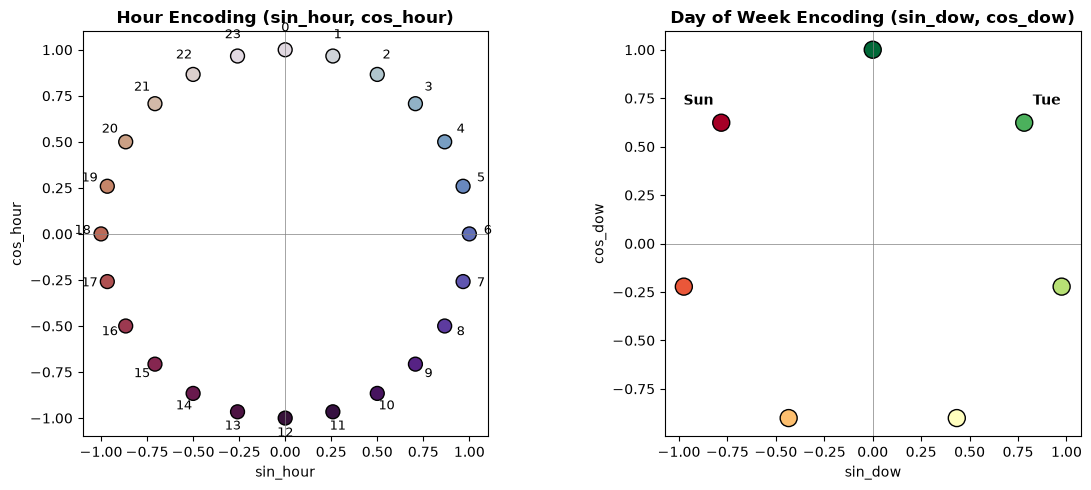

New columns: sin_hour, cos_hour, sin_dow, cos_dow


,step,sin_hour,cos_hour,sin_dow,cos_dow
0,1,0.258819,0.965926,0.0,1.0
1,1,0.258819,0.965926,0.0,1.0
2,1,0.258819,0.965926,0.0,1.0
3,1,0.258819,0.965926,0.0,1.0
4,1,0.258819,0.965926,0.0,1.0


In [4]:
# ============================================================
# Group 3: Time Features
# Cyclical encoding — no leakage risk.
# simulation_phase intentionally excluded (PaySim artifact).
# ============================================================

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute cyclical time features from step."""
    df = df.copy()

    hour = df["step"] % 24
    day_of_week = ((df["step"] - 1) // 24) % 7  # 0=Mon, 6=Sun

    df["sin_hour"] = np.sin(2 * np.pi * hour / 24)
    df["cos_hour"] = np.cos(2 * np.pi * hour / 24)
    df["sin_dow"] = np.sin(2 * np.pi * day_of_week / 7)
    df["cos_dow"] = np.cos(2 * np.pi * day_of_week / 7)

    return df


train = add_time_features(train)
val = add_time_features(val)
test = add_time_features(test)

# --- Quick validation: plot the circle ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hour circle
hours = np.arange(24)
axes[0].scatter(np.sin(2 * np.pi * hours / 24), np.cos(2 * np.pi * hours / 24), c=hours, cmap="twilight", s=100, edgecolors="black")
for h in hours:
    axes[0].annotate(str(h), (np.sin(2 * np.pi * h / 24) * 1.1, np.cos(2 * np.pi * h / 24) * 1.1), fontsize=9, ha="center")
axes[0].set_title("Hour Encoding (sin_hour, cos_hour)", fontweight="bold")
axes[0].set_xlabel("sin_hour"); axes[0].set_ylabel("cos_hour")
axes[0].axhline(0, color="gray", linewidth=0.5); axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].set_aspect("equal")

# DOW circle
dows = np.arange(7)
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].scatter(np.sin(2 * np.pi * dows / 7), np.cos(2 * np.pi * dows / 7), c=dows, cmap="RdYlGn_r", s=150, edgecolors="black")
for d, lbl in zip(dows, labels):
    axes[1].annotate(lbl, (np.sin(2 * np.pi * d / 7) * 1.15, np.cos(2 * np.pi * d / 7) * 1.15), fontsize=10, ha="center", fontweight="bold")
axes[1].set_title("Day of Week Encoding (sin_dow, cos_dow)", fontweight="bold")
axes[1].set_xlabel("sin_dow"); axes[1].set_ylabel("cos_dow")
axes[1].axhline(0, color="gray", linewidth=0.5); axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

print("New columns: sin_hour, cos_hour, sin_dow, cos_dow")
train[["step", "sin_hour", "cos_hour", "sin_dow", "cos_dow"]].head(5)

### Group 4: Behavioral Features (Chronological — Leakage-Safe)

These features require looking at each sender's **past** transactions only. We process all splits together chronologically by `step`, maintaining running state that accumulates as we move forward in time. This ensures:

- **Train rows** only see earlier train rows
- **Val rows** see all train + earlier val rows
- **Test rows** see all train+val + earlier test rows

| Feature | Window | What it catches |
|---|---|---|
| `velocity_1h` | 1 step | Rapid-fire bursts |
| `velocity_24h` | 24 steps | Daily activity spike |
| `velocity_3d` | 72 steps | Gradual ramp-up over days |
| `amount_zscore` | All past | "This amount is way bigger than normal for this sender" |
| `new_recipient_flag` | All past | First-time transfer to an unknown destination |
| `time_since_last_txn` | All past | Dormant account suddenly wakes up |

In [5]:
# ============================================================
# Group 4: Behavioral Features
# Chronological single-pass — NO future leakage.
# ============================================================

import bisect
from collections import defaultdict

# 1. Label splits and combine into one chronologically-sorted DataFrame
train["_split"] = "train"
val["_split"] = "val"
test["_split"] = "test"
all_data = pd.concat([train, val, test], ignore_index=True).sort_values("step").reset_index(drop=True)

# 2. Running state (accumulates as we iterate forward in time)
sender_steps: dict[str, list[int]] = defaultdict(list)       # sorted list of past step values
sender_amounts: dict[str, list[float]] = defaultdict(list)    # past amounts for zscore
sender_last_step: dict[str, int] = {}                          # most recent step seen
seen_pairs: set[tuple[str, str]] = set()                       # (nameOrig, nameDest) pairs

# 3. Output arrays (pre-allocate for speed)
n = len(all_data)
vel_1h = np.zeros(n, dtype=np.float64)
vel_24h = np.zeros(n, dtype=np.float64)
vel_3d = np.zeros(n, dtype=np.float64)
amount_z = np.zeros(n, dtype=np.float64)
new_recip = np.zeros(n, dtype=np.int8)
time_since = np.zeros(n, dtype=np.float64)

# 4. Single chronological pass
for i in range(n):
    row = all_data.iloc[i]
    orig = row["nameOrig"]
    dest = row["nameDest"]
    amt = row["amount"]
    step = row["step"]

    past_steps = sender_steps[orig]  # already sorted (we append in order)

    # --- Velocity features (binary search on sorted past steps) ---
    if past_steps:
        # Count txns in (step - window, step)
        vel_1h[i] = len(past_steps) - bisect.bisect_right(past_steps, step - 1)
        vel_24h[i] = len(past_steps) - bisect.bisect_right(past_steps, step - 24)
        vel_3d[i] = len(past_steps) - bisect.bisect_right(past_steps, step - 72)
    # else: stays 0 (no history)

    # --- Amount z-score ---
    past_amounts = sender_amounts[orig]
    if len(past_amounts) >= 2:
        mu = np.mean(past_amounts)
        sigma = np.std(past_amounts, ddof=1)
        if sigma > 0:
            amount_z[i] = (amt - mu) / sigma
    # else: stays 0 (not enough history)

    # --- New recipient flag ---
    pair = (orig, dest)
    if pair not in seen_pairs:
        new_recip[i] = 1

    # --- Time since last transaction ---
    if orig in sender_last_step:
        time_since[i] = step - sender_last_step[orig]
    else:
        time_since[i] = 999  # sentinel: first-ever transaction

    # --- Update running state AFTER computing features for this row ---
    sender_steps[orig].append(step)
    sender_amounts[orig].append(amt)
    sender_last_step[orig] = step
    seen_pairs.add(pair)

# 5. Attach features back to all_data
all_data["velocity_1h"] = vel_1h
all_data["velocity_24h"] = vel_24h
all_data["velocity_3d"] = vel_3d
all_data["amount_zscore"] = amount_z
all_data["new_recipient_flag"] = new_recip
all_data["time_since_last_txn"] = time_since

# 6. Split back into train/val/test
train = all_data[all_data["_split"] == "train"].drop(columns=["_split"]).copy()
val = all_data[all_data["_split"] == "val"].drop(columns=["_split"]).copy()
test = all_data[all_data["_split"] == "test"].drop(columns=["_split"]).copy()

# --- Quick validation ---
print("=== Velocity 1h stats (Train) ===")
v = train["velocity_1h"]
print(f"  Mean: {v.mean():.2f} | Median: {v.median():.1f} | Max: {v.max():.0f} | >0: {(v > 0).mean()*100:.1f}%")

print("\n=== Amount Z-score stats (Train) ===")
z = train["amount_zscore"]
nonzero = z[z != 0]
print(f"  Nonzero rows: {len(nonzero):,} ({len(nonzero)/len(train)*100:.1f}%)")
print(f"  Mean: {nonzero.mean():.2f} | Std: {nonzero.std():.2f} | Max: {nonzero.max():.2f}")

print("\n=== New Recipient Flag (Train) ===")
nr = train["new_recipient_flag"]
print(f"  New recipient: {nr.sum():,} ({nr.mean()*100:.1f}%)")
fraud_nr = train[train["isFraud"] == 1]["new_recipient_flag"].mean() * 100
legit_nr = train[train["isFraud"] == 0]["new_recipient_flag"].mean() * 100
print(f"  Fraud new-recipient rate: {fraud_nr:.1f}% | Legit: {legit_nr:.1f}%")

print("\n=== Time Since Last Txn (Train) ===")
ts = train["time_since_last_txn"]
sentinel = (ts == 999).sum()
print(f"  Sentinel (999): {sentinel:,} ({sentinel/len(train)*100:.1f}%)")
print(f"  Non-sentinel mean: {ts[ts != 999].mean():.1f} steps | Median: {ts[ts != 999].median():.1f}")

print("\nNew columns: velocity_1h, velocity_24h, velocity_3d, amount_zscore, new_recipient_flag, time_since_last_txn")
train[["step", "nameOrig", "nameDest", "amount", "velocity_1h", "velocity_24h",
       "amount_zscore", "new_recipient_flag", "time_since_last_txn", "isFraud"]].head(10)

=== Velocity 1h stats (Train) ===
  Mean: 0.00 | Median: 0.0 | Max: 1 | >0: 0.0%

=== Amount Z-score stats (Train) ===
  Nonzero rows: 3 (0.0%)
  Mean: -1.74 | Std: 2.40 | Max: -0.04

=== New Recipient Flag (Train) ===
  New recipient: 2,701,957 (100.0%)
  Fraud new-recipient rate: 100.0% | Legit: 100.0%

=== Time Since Last Txn (Train) ===
  Sentinel (999): 2,700,260 (99.9%)
  Non-sentinel mean: 144.7 steps | Median: 133.0

New columns: velocity_1h, velocity_24h, velocity_3d, amount_zscore, new_recipient_flag, time_since_last_txn


,step,nameOrig,nameDest,amount,velocity_1h,velocity_24h,amount_zscore,new_recipient_flag,time_since_last_txn,isFraud
0,1,C1305486145,C553264065,181.00,0.0,0.0,0.0,1,999.0,1
1,1,C1733619456,C317071334,139555.44,0.0,0.0,0.0,1,999.0,0
2,1,C615853374,C564160838,130470.14,0.0,0.0,0.0,1,999.0,0
3,1,C366916060,C836514715,722161.86,0.0,0.0,0.0,1,999.0,0
4,1,C1048128739,C665576141,315325.25,0.0,0.0,0.0,1,999.0,0
5,1,C428245792,C1291286504,40149.38,0.0,0.0,0.0,1,999.0,0
6,1,C195970976,C1789550256,358124.44,0.0,0.0,0.0,1,999.0,0
7,1,C237484673,C357863579,151768.14,0.0,0.0,0.0,1,999.0,0
8,1,C61304908,C800281454,9533.48,0.0,0.0,0.0,1,999.0,0
9,1,C1851522556,C1170794006,333946.96,0.0,0.0,0.0,1,999.0,0


### Feature Engineering Summary

**Total features created: 16**

| # | Feature | Group | Type |
|---|---|---|---|
| 1 | `orig_error` | Balance | Continuous |
| 2 | `dest_error` | Balance | Continuous |
| 3 | `has_orig_error` | Balance | Binary (inverted signal) |
| 4 | `has_dest_error` | Balance | Binary |
| 5 | `is_transfer` | Type | Binary |
| 6 | `amount_log` | Amount | Continuous |
| 7 | `balance_emptying_ratio` | Amount | Continuous (-1 sentinel) |
| 8 | `sin_hour` | Time | Continuous [-1, 1] |
| 9 | `cos_hour` | Time | Continuous [-1, 1] |
| 10 | `sin_dow` | Time | Continuous [-1, 1] |
| 11 | `cos_dow` | Time | Continuous [-1, 1] |
| 12 | `velocity_1h` | Behavioral | Count |
| 13 | `velocity_24h` | Behavioral | Count |
| 14 | `velocity_3d` | Behavioral | Count |
| 15 | `amount_zscore` | Behavioral | Continuous (0 = no history) |
| 16 | `new_recipient_flag` | Behavioral | Binary |
| 17 | `time_since_last_txn` | Behavioral | Continuous (999 sentinel) |

**Columns kept from raw data:** `step`, `type`, `amount`, `nameOrig`, `nameDest`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`, `isFraud`, `isFlaggedFraud`

**Next:** `notebooks/04-model-training.ipynb` — reads these DataFrames, selects feature columns, trains XGBoost.

In [6]:
# ============================================================
# Save feature-engineered splits for 04-model-training.ipynb
# ============================================================
from pathlib import Path

FEATURES_DIR = Path("../ml/data/features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

train.to_parquet(FEATURES_DIR / "train_features.parquet", index=False)
val.to_parquet(FEATURES_DIR / "val_features.parquet", index=False)
test.to_parquet(FEATURES_DIR / "test_features.parquet", index=False)

print("✅ Saved to ml/data/features/:")
for f in sorted(FEATURES_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name} ({size_mb:.1f} MB)")

print(f"\nFinal columns ({len(train.columns)}):")
print(train.columns.tolist())

✅ Saved to ml/data/features/:
  test_features.parquet (2.3 MB)
  train_features.parquet (183.3 MB)
  val_features.parquet (2.3 MB)

Final columns (28):
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'orig_error', 'dest_error', 'has_orig_error', 'has_dest_error', 'is_transfer', 'amount_log', 'balance_emptying_ratio', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'velocity_1h', 'velocity_24h', 'velocity_3d', 'amount_zscore', 'new_recipient_flag', 'time_since_last_txn']
